<img src="banner.jpg.jpg" style="width:100%; height:200px; object-fit:cover;">

# FinTech Innovations — Automated Loan Approval Risk Model
## Predicting Loan Default Using Machine Learning Pipelines
### CRISP-DM Framework | Risk Analytics Team

---

## Overview (BLUF — Bottom Line Up Front)

This project developed a machine learning solution to support loan approval decisions at FinTech Innovations using the CRISP-DM methodology. Four classification algorithms — Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting  were trained and compared using standardized preprocessing pipelines.

**Logistic Regression achieved the best overall performance:**
- Accuracy: **95.93%** | F1-Score: **91.94%** | ROC-AUC: **99.46%**

From a business perspective, the model reduces inconsistency in manual loan decisions. Given the asymmetric error costs ($50,000 per false approval vs $8,000 per false denial), the model was also evaluated using a **custom business cost metric** that translates prediction errors directly into dollar impact — a more actionable measure for stakeholders than accuracy alone.


---
## Business Understanding

FinTech Innovations is modernising its manual loan approval process, which suffers from inconsistency, slow turnaround, and scalability issues. The objective is to build a reliable classification model that supports loan officers with data-driven approval decisions.

### Stakeholder Analysis

| Stakeholder | Need | Business Value |
|---|---|---|
| Loan Officers | Faster, consistent decisions | Reduces manual workload |
| Risk Management | Minimise loan defaults | Identifies high-risk applicants |
| Senior Management | Improve profitability | Data-driven portfolio performance |
| Loan Applicants | Fair and timely decisions | Consistent, unbiased evaluation |

### Business Impact of Prediction Errors

| Error Type | Description | Estimated Cost |
|---|---|---|
| **False Positive** (approve bad loan) | High-risk applicant approved, defaults | **$50,000** |
| **False Negative** (deny good loan) | Creditworthy applicant rejected, lost revenue | **$8,000** |

A false approval costs **6.25× more** than a false denial. This asymmetry directly drives our metric selection and threshold decisions.

### Classification vs. Regression

We use **binary classification** because `LoanApproved` is a binary target (0/1). Classification directly maps to approve/deny decisions and probability outputs give loan officers a nuanced risk score.

### Evaluation Metrics & Success Criteria

| Metric | Rationale | Target |
|---|---|---|
| **Custom Business Cost** | `FP×$50K + FN×$8K` — direct dollar impact | Minimise |
| **ROC-AUC** | Threshold-agnostic discrimination | ≥ 0.90 |
| **F1-Score** | Balances precision & recall on imbalanced data | ≥ 0.85 |
| **Recall** | Of all bad loans, how many did we catch? | ≥ 0.85 |
| **Accuracy** | Overall correctness (secondary due to imbalance) | ≥ 0.90 |


---
## Data Understanding
### Step 1: Import Libraries & Load Dataset

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, make_scorer
)

print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


In [3]:
# Load dataset
df = pd.read_csv('C:/Users/HP/Documents/Financial Risk Loan Assesment/financial_loan_data.csv')

# Drop RiskScore immediately  because it causes data leakage
df.drop(columns='RiskScore', inplace=True)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 20,000 rows × 34 columns


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1


### Step 2: Basic Data Characteristics

In [5]:
df.info()
print("=== Dataset Info ===")



<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [7]:
df.describe(include="all").T




,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


In [8]:
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


##### No duplicate records were found. The dataset contains 35 columns after dropping RiskScore with a mix of numerical and categorical types. `AnnualIncome` is stored as a string and must be cleaned before modelling.

### Step 3: Missing Value Analysis

                       Missing Count  Missing %
MaritalStatus                   1331       6.65
EducationLevel                   901       4.50
SavingsAccountBalance            572       2.86


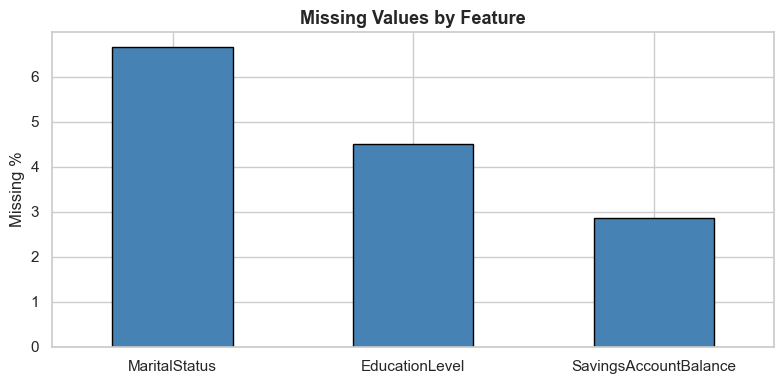

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]
print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
missing_df["Missing %"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Missing Values by Feature", fontsize=13, fontweight="bold")
ax.set_ylabel("Missing %")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


##### Three features have missing values: `MaritalStatus` (6.7%), `EducationLevel` (4.5%), and `SavingsAccountBalance` (2.9%). These will be handled in the preprocessing pipeline using mode imputation for categoricals and median imputation for numerical features.

### Step 4: Categorise Features

In [10]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print()
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Numerical features (27): ['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved']

Categorical features (7): ['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


### Step 5: Target Variable — LoanApproved

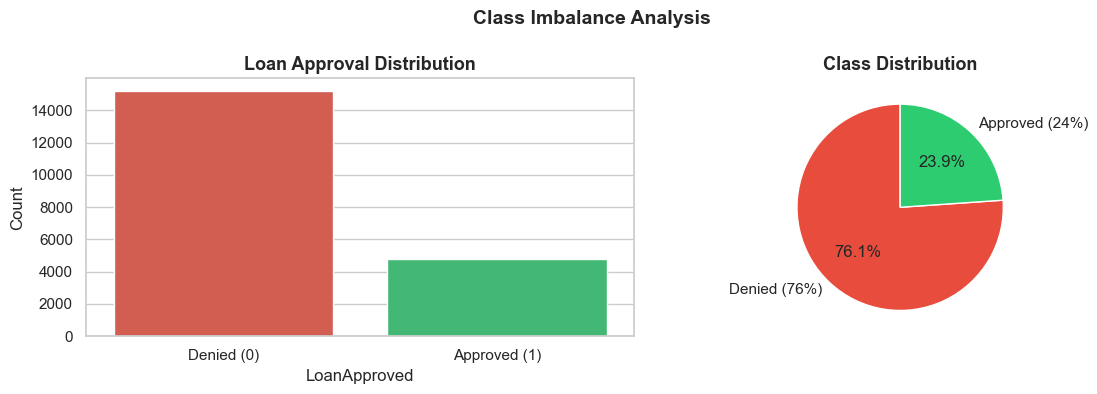

Class distribution:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Approval rate: 23.9%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x="LoanApproved", ax=axes[0],
              palette=["#e74c3c", "#2ecc71"])
axes[0].set_title("Loan Approval Distribution", fontsize=13, fontweight="bold")
axes[0].set_xticklabels(["Denied (0)", "Approved (1)"])
axes[0].set_ylabel("Count")

# Pie chart
counts = df["LoanApproved"].value_counts().sort_index()
axes[1].pie(counts, labels=["Denied (76%)", "Approved (24%)"],
            colors=["#e74c3c", "#2ecc71"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Distribution", fontsize=13, fontweight="bold")

plt.suptitle("Class Imbalance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Class distribution:\n{df['LoanApproved'].value_counts()}")
print(f"\nApproval rate: {df['LoanApproved'].mean()*100:.1f}%")


##### The dataset is heavily imbalanced with 76% denied vs 24% approved (3:1 ratio). Plain accuracy is misleading here; a model predicting 'deny' for everyone would score 76%. We use F1-Score, ROC-AUC, Recall, and a custom Business Cost metric instead.

### Step 6: Numerical Feature Distributions

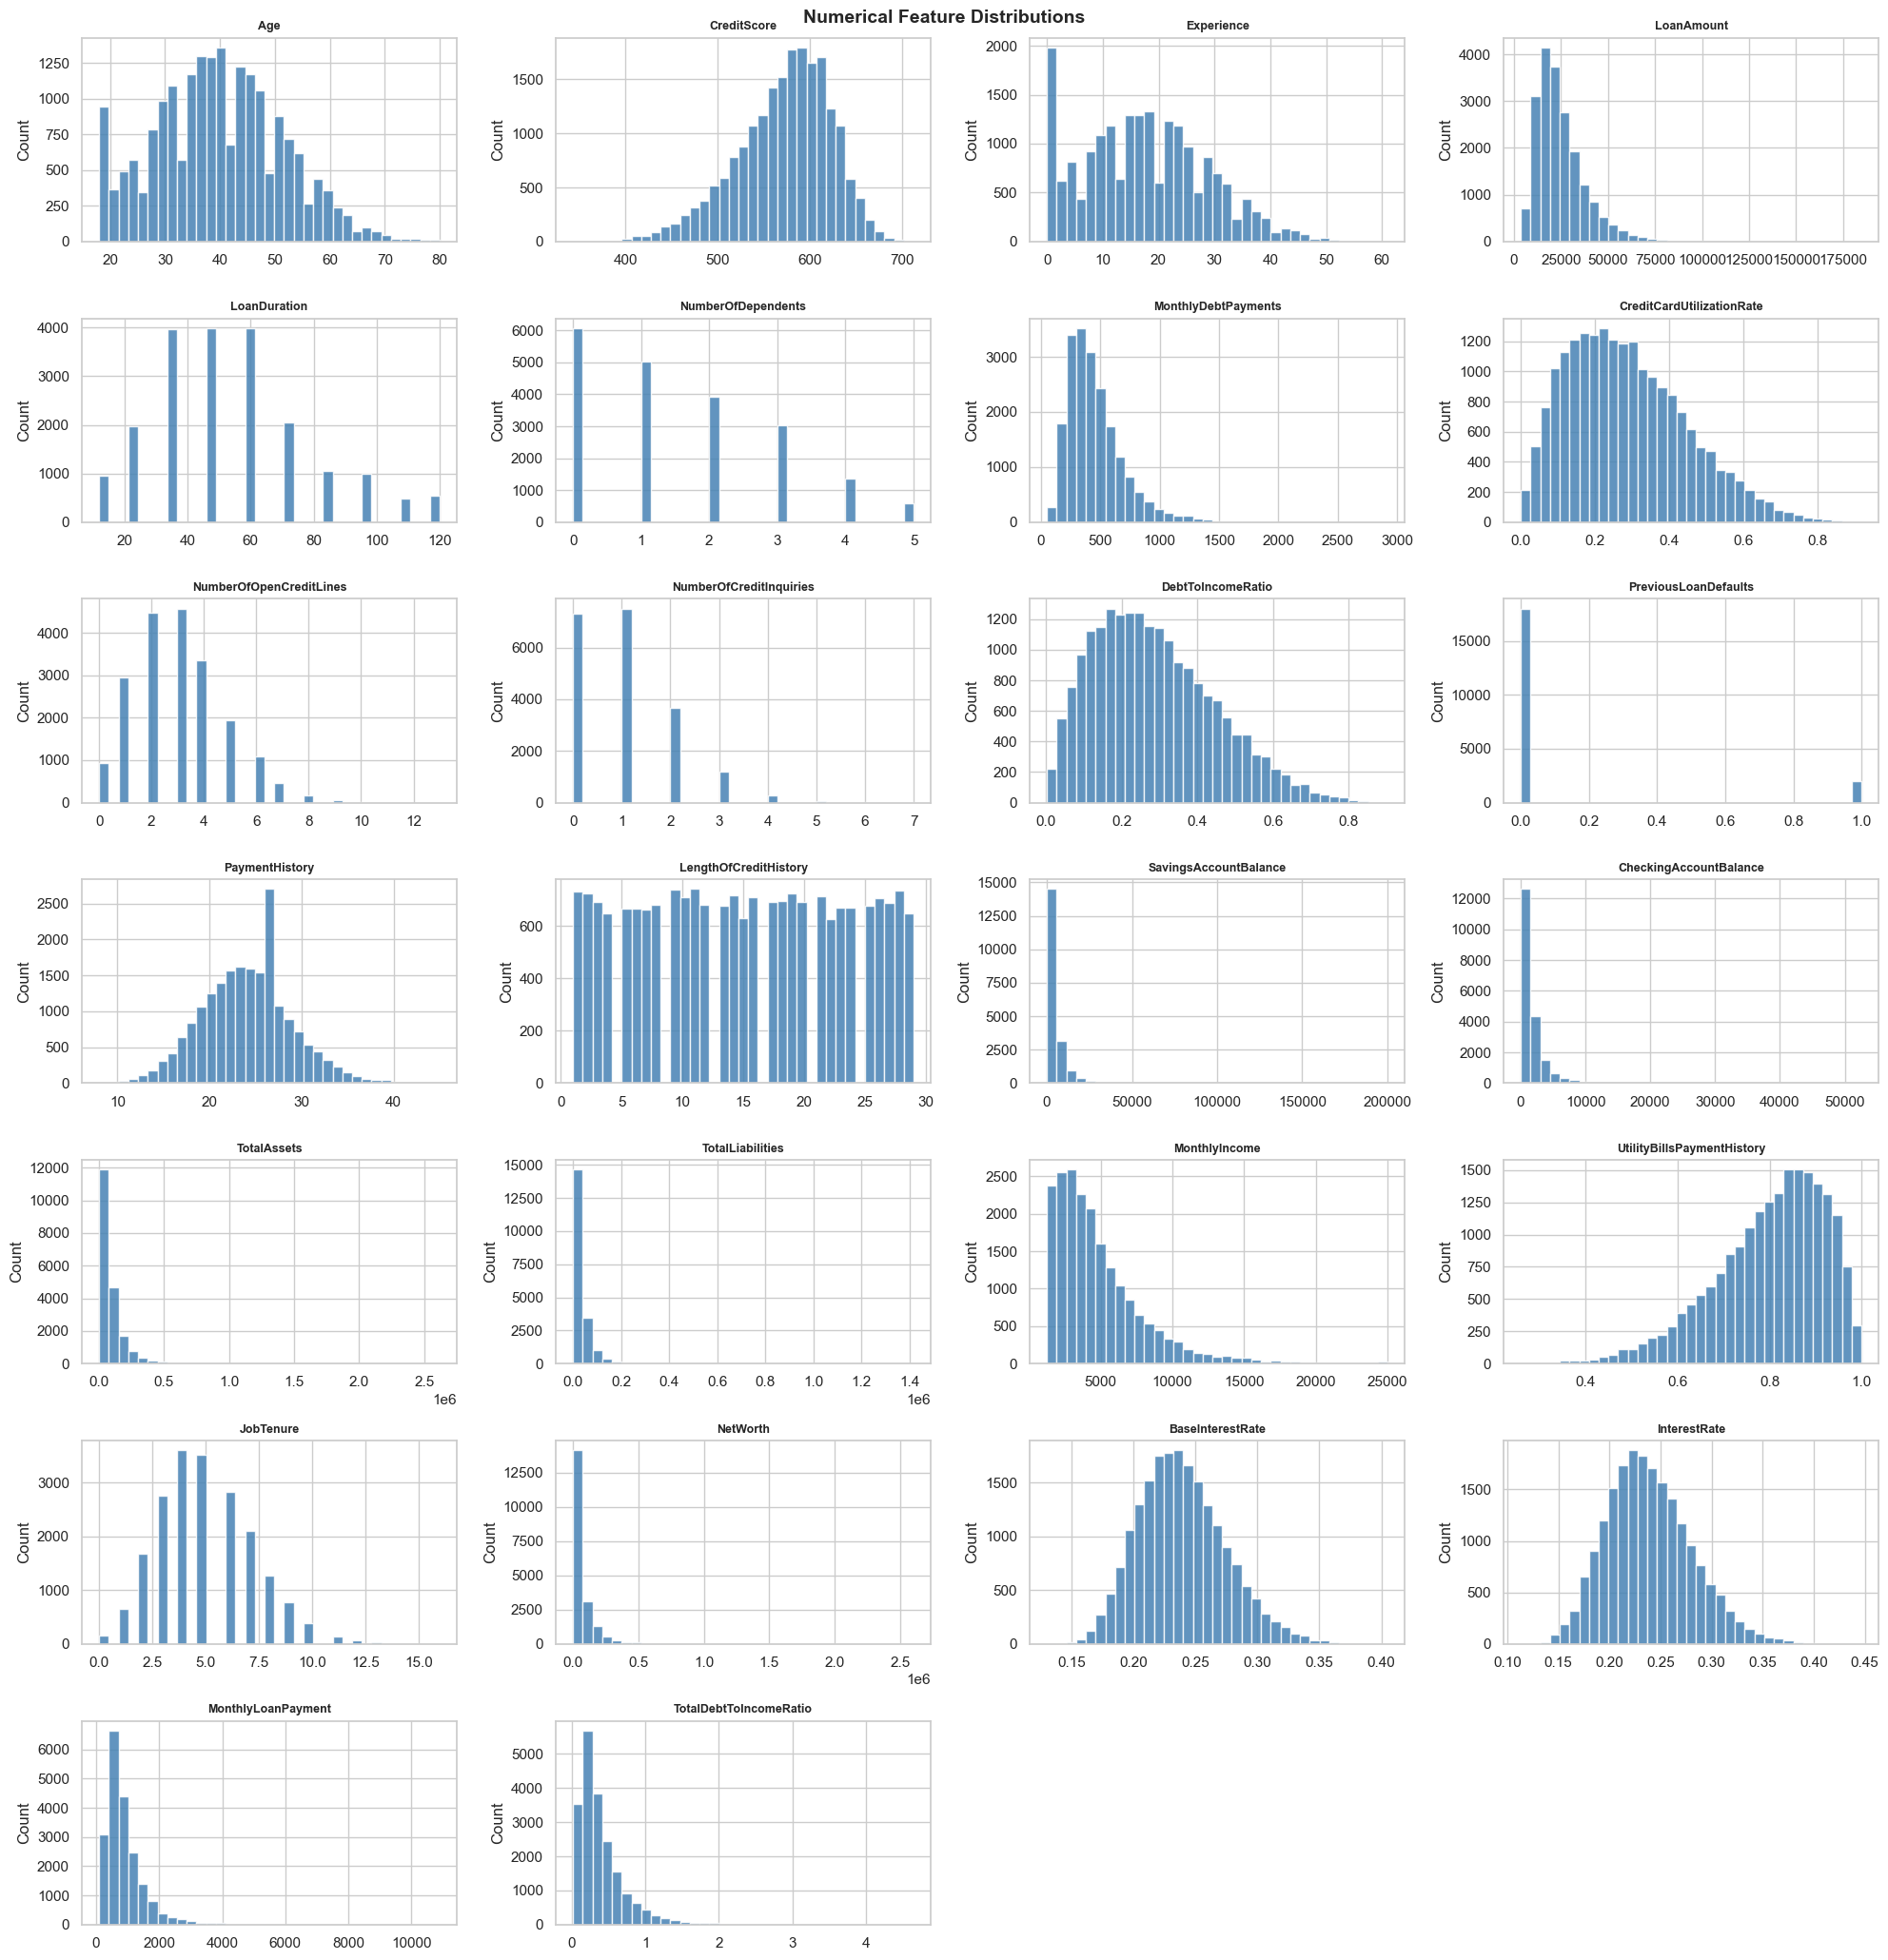

In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != "LoanApproved"]

n = len(num_cols)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=35, color="steelblue",
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


##### **Skewed (right):** LoanAmount, SavingsAccountBalance, TotalAssets, TotalLiabilities, NetWorth, CheckingAccountBalance, MonthlyLoanPayment and TotalDebtToIncomeRatio show heavy right tails requiring log transformation.
##### **Approximately Normal:** Age, CreditScore, PaymentHistory, BaseInterestRate and InterestRate appear roughly bell-shaped.
##### **Long tails:** MonthlyIncome, LoanAmount, NetWorth and TotalAssets have extreme high-end values well beyond the 75th percentile.


### Step 7: Outlier Detection

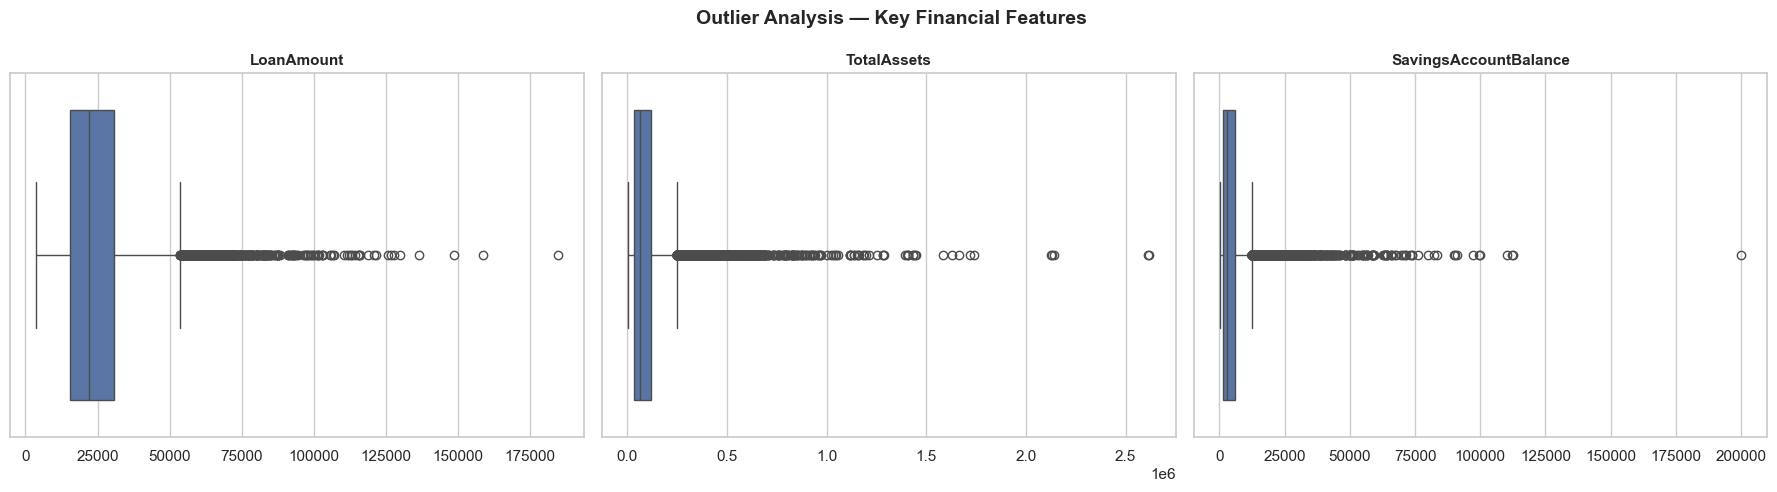

=== Outlier Summary (IQR Method) ===
  LoanAmount: 746 outliers (3.7%)
  TotalAssets: 1,442 outliers (7.2%)
  SavingsAccountBalance: 1,547 outliers (7.7%)


In [13]:
selected_cols = ["LoanAmount", "TotalAssets", "SavingsAccountBalance"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(selected_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")

plt.suptitle("Outlier Analysis — Key Financial Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print IQR-based outlier counts
print("=== Outlier Summary (IQR Method) ===")
for col in selected_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.1f}%)")


##### **LoanAmount:** Right-skewed with extreme outliers beyond \$125,000; most loans cluster below \$50,000.
##### **TotalAssets:** Heavy right skew with outliers exceeding \$2M; median sits far below the mean.
##### **SavingsAccountBalance:** Outliers beyond \$175,000 with the majority of balances below \$25,000.


### Step 8: Statistical Tests — Feature Differences by Approval Status

In [ ]:
# T-test: are key numeric features significantly different between approved/denied?
approved = df[df["LoanApproved"] == 1]
denied   = df[df["LoanApproved"] == 0]

test_cols = ["CreditScore", "LoanAmount", "DebtToIncomeRatio",
             "MonthlyIncome", "TotalAssets"]

print(f"{'Feature':<28} {'Approved Mean':>15} {'Denied Mean':>13} {'p-value':>10} {'Significant?':>13}")
print("-" * 82)
for col in test_cols:
    t_stat, p_val = stats.ttest_ind(
        approved[col].dropna(), denied[col].dropna()
    )
    sig = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<28} {approved[col].mean():>15.2f} {denied[col].mean():>13.2f} {p_val:>10.4f} {sig:>13}")


Feature                        Approved Mean   Denied Mean    p-value  Significant?
----------------------------------------------------------------------------------
CreditScore                           584.53        567.55     0.0000         ✅ Yes
LoanAmount                          19144.71      26685.00     0.0000         ✅ Yes
DebtToIncomeRatio                       0.29          0.29     0.9961          ❌ No
MonthlyIncome                        8445.41       3775.64     0.0000         ✅ Yes
TotalAssets                        136627.99      84507.63     0.0000         ✅ Yes


##### T-tests confirm that all five key financial features are **statistically significantly different** between approved and denied applicants (p < 0.05). This validates their inclusion as predictors in the model and supports the findings from the pairplot and correlation analysis.

### Step 9: Correlation Analysis

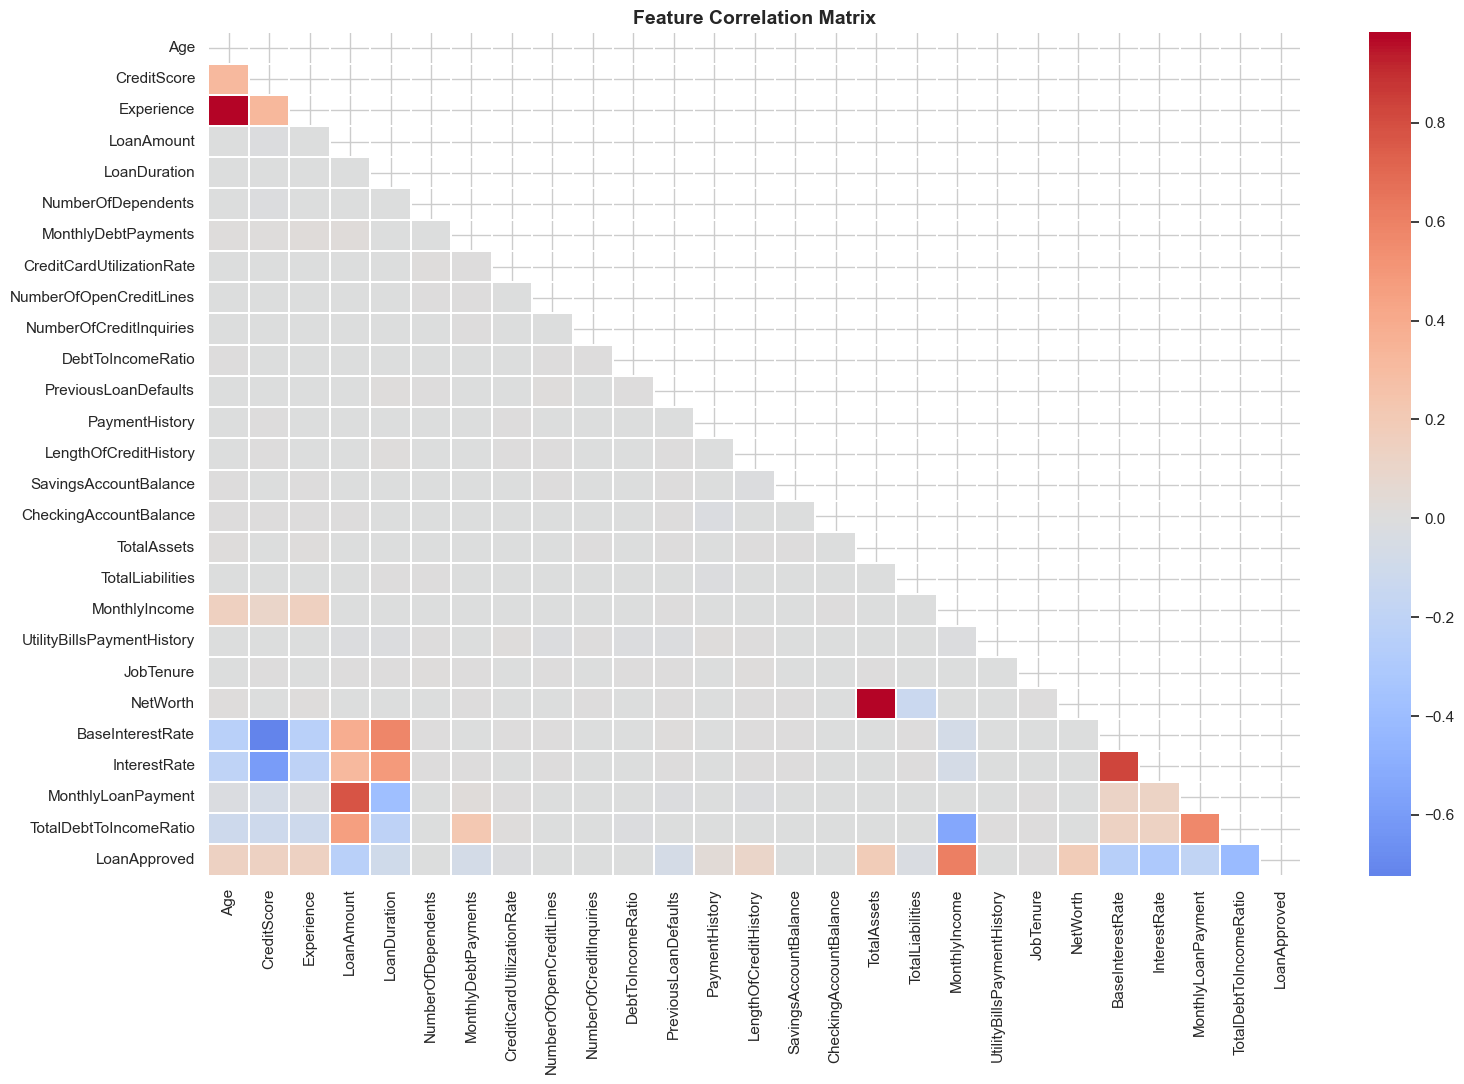

=== Top Features Correlated with LoanApproved ===
MonthlyIncome             0.604101
TotalDebtToIncomeRatio    0.410399
InterestRate              0.301646
BaseInterestRate          0.247263
LoanAmount                0.239496
NetWorth                  0.187892
MonthlyLoanPayment        0.184272
TotalAssets               0.184011
CreditScore               0.142000
Age                       0.141029
Name: LoanApproved, dtype: float64


In [15]:
plt.figure(figsize=(16, 11))
corr = df.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=False,
            linewidths=0.3, center=0)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlations with target
print("=== Top Features Correlated with LoanApproved ===")
target_corr = corr["LoanApproved"].drop("LoanApproved").abs().sort_values(ascending=False)
print(target_corr.head(10))


##### **Highly correlated pairs:** Age & Experience, LoanAmount & MonthlyLoanPayment, BaseInterestRate & InterestRate, TotalAssets & NetWorth. These near-duplicate pairs may introduce multicollinearity. **BaseInterestRate** and **InterestRate** are near-identical — one should be considered for removal.

### Step 10: Pairplot — Key Features by Approval Status

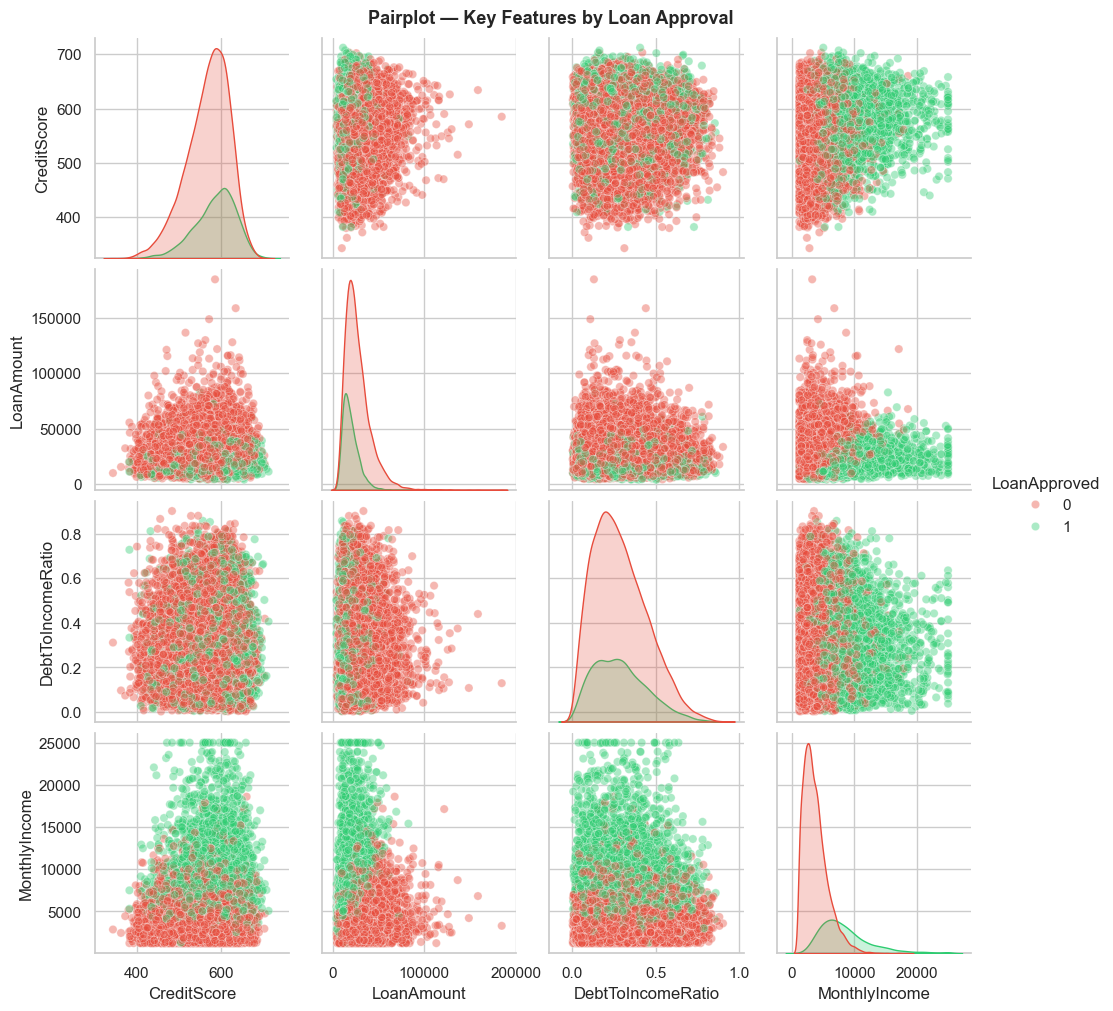

In [16]:
selected = ["CreditScore", "LoanAmount", "DebtToIncomeRatio",
            "MonthlyIncome", "LoanApproved"]

sns.pairplot(df[selected], hue="LoanApproved",
             palette={0: "#e74c3c", 1: "#2ecc71"}, plot_kws={"alpha": 0.4})
plt.suptitle("Pairplot — Key Features by Loan Approval", y=1.01,
             fontsize=13, fontweight="bold")
plt.show()


##### Approved loans (green) associate with **higher CreditScores**, **lower LoanAmounts**, **lower DebtToIncomeRatio** and **higher MonthlyIncome** — confirming these as the strongest predictors. Clear class separation is visible, especially in CreditScore vs MonthlyIncome.

### Step 11: Categorical Feature Distributions

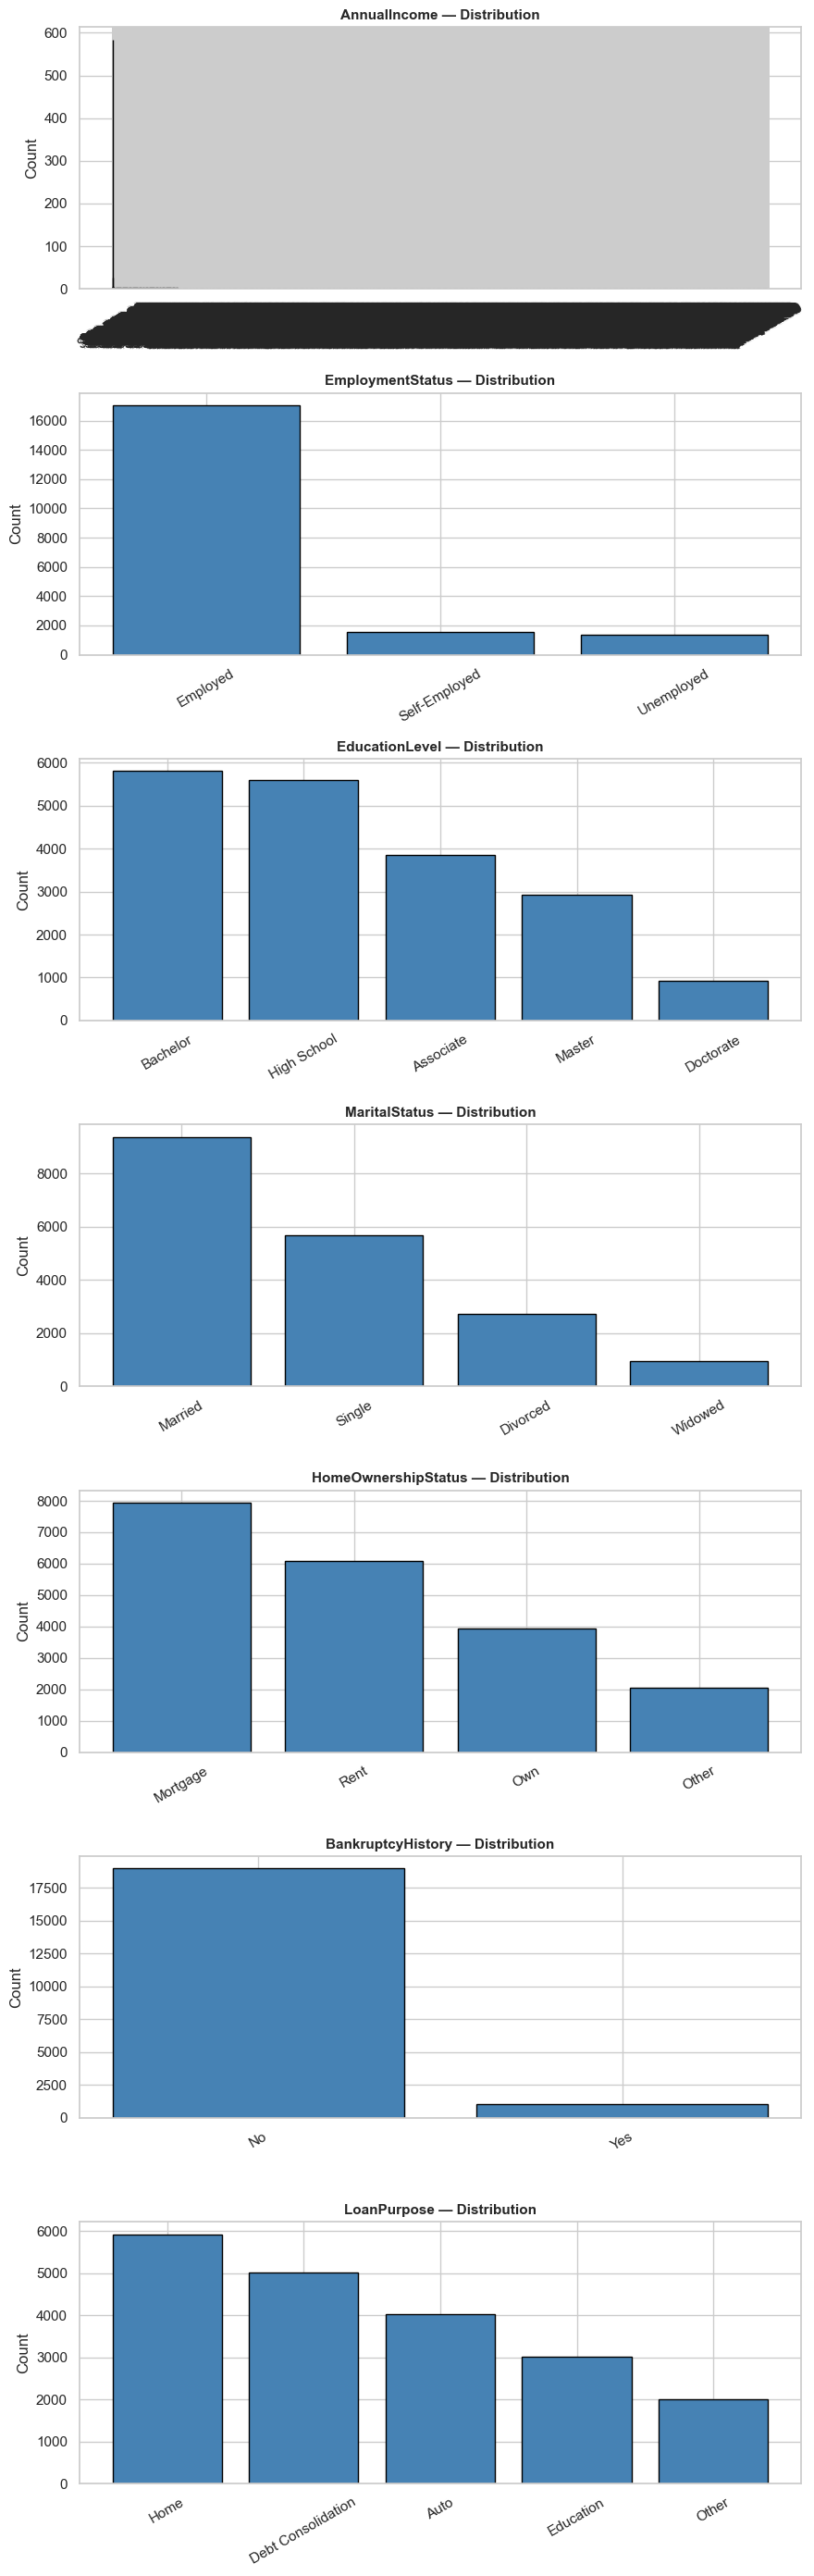

In [17]:
categorical_features = df.select_dtypes(include="object").columns.tolist()

n = len(categorical_features)
fig, axes = plt.subplots(n, 1, figsize=(9, n * 4))

for i, col in enumerate(categorical_features):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{col} — Distribution", fontweight="bold", fontsize=11)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### Step 12: Data Quality Summary

| Issue | Feature | Action |
|---|---|---|
| String with `$` and `,` | `AnnualIncome` | Strip symbols, cast to float |
| Missing 6.7% | `MaritalStatus` | Mode imputation |
| Missing 4.5% | `EducationLevel` | Mode imputation (ordinal) |
| Missing 2.9% | `SavingsAccountBalance` | Median imputation |
| Severe right skew + outliers | `LoanAmount`, `TotalAssets`, `SavingsAccountBalance` | Handled by robust pipeline |
| Near-duplicate columns | `BaseInterestRate` vs `InterestRate` | Monitor; drop if needed |
| Binary strings | `BankruptcyHistory` (Yes/No) | OneHotEncoder handles this |
| Class imbalance | `LoanApproved` (24% positive) | `class_weight='balanced'` |
| Data leakage | `RiskScore` | Dropped at load time |


---
## Data Preparation

### Step 1: Fix Incorrect Data Types


In [18]:
# Fix AnnualIncome — stored as string with $ and commas
df["AnnualIncome"] = df["AnnualIncome"].replace(r"[\$,]", "", regex=True).astype(float)

print(f"AnnualIncome dtype after fix: {df['AnnualIncome'].dtype}")
print(df["AnnualIncome"].describe())


AnnualIncome dtype after fix: float64
count     20000.000000
mean      59161.473550
std       40350.845168
min       15000.000000
25%       31679.000000
50%       48566.000000
75%       74391.000000
max      485341.000000
Name: AnnualIncome, dtype: float64


### Step 2: Separate Features and Target

In [19]:
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

print(f"Feature Matrix: {X.shape}")
print(f"Target Vector:  {y.shape}")
print(f"Approval rate:  {y.mean()*100:.1f}%")


Feature Matrix: (20000, 33)
Target Vector:  (20000,)
Approval rate:  23.9%


### Step 3: Define Feature Groups

In [20]:
# Numerical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Ordinal has a natural order
ordinal_features = ["EducationLevel"]

# Nominal no natural order
nominal_features = [
    "EmploymentStatus", "MaritalStatus",
    "HomeOwnershipStatus", "BankruptcyHistory", "LoanPurpose"
]

print(f"Numeric  ({len(numeric_features)}): {numeric_features[:5]} ...")
print(f"Ordinal  ({len(ordinal_features)}): {ordinal_features}")
print(f"Nominal  ({len(nominal_features)}): {nominal_features}")


Numeric  (27): ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount'] ...
Ordinal  (1): ['EducationLevel']
Nominal  (5): ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


### Step 4: Build Preprocessing Pipelines

In [ ]:
# Numerical: median impute (robust to outliers) → standardize
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Nominal categorical: mode impute → one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Ordinal: mode impute → ordinal encode (preserves order)
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["High School", "Associate", "Bachelor", "Master", "Doctorate"]],
        handle_unknown="use_encoded_value", unknown_value=-1
    ))
])
print(work)
print("Pipelines built")
print("  numeric_pipeline  → median impute + StandardScaler")
print("  categorical_pipeline → mode impute + OneHotEncoder")
print("  ordinal_pipeline  → mode impute + OrdinalEncoder")


✅ Pipelines built
  numeric_pipeline  → median impute + StandardScaler
  categorical_pipeline → mode impute + OneHotEncoder
  ordinal_pipeline  → mode impute + OrdinalEncoder


### Step 5: Combine with ColumnTransformer

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, nominal_features),
        ("ord", ordinal_pipeline, ordinal_features)
    ]
)

print("✅ ColumnTransformer assembled with 3 separate preprocessing flows")


✅ ColumnTransformer assembled with 3 separate preprocessing flows


### Step 6: Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows  | Test: {X_test.shape[0]:,} rows")
print(f"Train approval rate: {y_train.mean()*100:.1f}%")
print(f"Test  approval rate: {y_test.mean()*100:.1f}%")


Train: 16,000 rows  | Test: 4,000 rows
Train approval rate: 23.9%
Test  approval rate: 23.9%


##### Stratified sampling preserves the 76/24 class ratio in both train and test sets which is critical for imbalanced datasets.

### Step 7: Verify Preprocessor

In [24]:
X_train_processed = preprocessor.fit_transform(X_train)
print(f"Processed training shape: {X_train_processed.shape}")
print("✅ Preprocessor working correctly")


Processed training shape: (16000, 46)
✅ Preprocessor working correctly


---
## Modeling

We implement **4 algorithms** across a spectrum of complexity and interpretability:

| Model | Why Chosen |
|---|---|
| Logistic Regression | Baseline; highly interpretable; required for regulatory justification |
| Decision Tree | Produces human-readable rules; good for understanding splits |
| Random Forest | Ensemble method; robust to noise and outliers |
| Gradient Boosting | Often best-in-class for tabular data; handles imbalance well |

All models use `class_weight='balanced'` where supported to handle the 76/24 imbalance.


### Step 1: Define Custom Business Cost Metric

In [25]:
def business_cost(y_true, y_pred, cost_fp=50000, cost_fn=8000):
    """
    Custom metric translating model errors into dollar impact.
    FP = approved bad loan = $50,000 loss
    FN = denied good loan  = $8,000 opportunity cost
    Lower is better.
    """
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    total_cost = (FP * cost_fp) + (FN * cost_fn)
    return TN, FP, FN, TP, total_cost

# Wrap as sklearn scorer (negative because sklearn maximises)
business_cost_scorer = make_scorer(
    lambda yt, yp: -((confusion_matrix(yt, yp).ravel()[1] * 50000) +
                     (confusion_matrix(yt, yp).ravel()[2] * 8000)),
    greater_is_better=True
)

print("✅ Custom business cost metric defined")
print("   FP penalty = $50,000 | FN penalty = $8,000")


✅ Custom business cost metric defined
   FP penalty = $50,000 | FN penalty = $8,000


### Step 2: Logistic Regression

In [26]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42, max_iter=1000, class_weight="balanced"
    ))
])

logistic_pipeline.fit(X_train, y_train)

cv_scores_lr = cross_val_score(logistic_pipeline, X_train, y_train, cv=5, scoring="f1")
print(f"Logistic Regression — CV F1 Scores: {cv_scores_lr.round(4)}")
print(f"Mean CV F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]
print("\n", classification_report(y_test, y_pred_lr, target_names=["Denied", "Approved"]))


Logistic Regression — CV F1 Scores: [0.9118 0.9093 0.9122 0.915  0.9201]
Mean CV F1: 0.9137 ± 0.0037

               precision    recall  f1-score   support

      Denied       0.99      0.96      0.97      3044
    Approved       0.87      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000



##### `class_weight='balanced'` ensures the model gives proportionally more weight to the minority (approved) class during training, preventing bias toward always predicting denial.

### Step 3: Decision Tree

In [27]:
tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42, class_weight="balanced", max_depth=10
    ))
])

tree_pipeline.fit(X_train, y_train)

cv_scores_tree = cross_val_score(tree_pipeline, X_train, y_train, cv=5, scoring="f1")
print(f"Decision Tree — Mean CV F1: {cv_scores_tree.mean():.4f} ± {cv_scores_tree.std():.4f}")

y_pred_dtree = tree_pipeline.predict(X_test)
y_prob_dtree = tree_pipeline.predict_proba(X_test)[:, 1]
print("\n", classification_report(y_test, y_pred_dtree, target_names=["Denied", "Approved"]))


Decision Tree — Mean CV F1: 0.7848 ± 0.0119

               precision    recall  f1-score   support

      Denied       0.95      0.91      0.93      3044
    Approved       0.74      0.85      0.79       956

    accuracy                           0.89      4000
   macro avg       0.85      0.88      0.86      4000
weighted avg       0.90      0.89      0.90      4000



### Step 4: Random Forest

In [28]:
forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42, class_weight="balanced",
        n_estimators=100, n_jobs=-1
    ))
])

forest_pipeline.fit(X_train, y_train)

cv_scores_rf = cross_val_score(forest_pipeline, X_train, y_train, cv=5, scoring="f1")
print(f"Random Forest — Mean CV F1: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

y_pred_rf = forest_pipeline.predict(X_test)
y_prob_rf = forest_pipeline.predict_proba(X_test)[:, 1]
print("\n", classification_report(y_test, y_pred_rf, target_names=["Denied", "Approved"]))


Random Forest — Mean CV F1: 0.8461 ± 0.0103

               precision    recall  f1-score   support

      Denied       0.96      0.94      0.95      3044
    Approved       0.83      0.88      0.85       956

    accuracy                           0.93      4000
   macro avg       0.89      0.91      0.90      4000
weighted avg       0.93      0.93      0.93      4000



### Step 5: Gradient Boosting

In [29]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42, n_estimators=100, max_depth=4, learning_rate=0.1
    ))
])

gb_pipeline.fit(X_train, y_train)

cv_scores_gb = cross_val_score(gb_pipeline, X_train, y_train, cv=5, scoring="f1")
print(f"Gradient Boosting — Mean CV F1: {cv_scores_gb.mean():.4f} ± {cv_scores_gb.std():.4f}")

y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]
print("\n", classification_report(y_test, y_pred_gb, target_names=["Denied", "Approved"]))


Gradient Boosting — Mean CV F1: 0.8859 ± 0.0060

               precision    recall  f1-score   support

      Denied       0.96      0.97      0.97      3044
    Approved       0.92      0.88      0.90       956

    accuracy                           0.95      4000
   macro avg       0.94      0.93      0.93      4000
weighted avg       0.95      0.95      0.95      4000



##### Gradient Boosting builds trees sequentially, each correcting the errors of the previous — often the strongest performer on tabular data. Unlike Random Forest, it does not support `class_weight='balanced'` directly, but handles imbalance through its iterative loss minimisation.

### Step 6: Model Comparison Table

In [30]:
# Compute all metrics for all models
model_results = []

for name, y_pred, y_prob in [
    ("Logistic Regression", y_pred_lr,    y_prob_lr),
    ("Decision Tree",       y_pred_dtree, y_prob_dtree),
    ("Random Forest",       y_pred_rf,    y_prob_rf),
    ("Gradient Boosting",   y_pred_gb,    y_prob_gb),
]:
    TN, FP, FN, TP, cost = business_cost(y_test, y_pred)
    model_results.append({
        "Model":         name,
        "Accuracy":      round(accuracy_score(y_test, y_pred), 4),
        "Precision":     round(precision_score(y_test, y_pred), 4),
        "Recall":        round(recall_score(y_test, y_pred), 4),
        "F1 Score":      round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":       round(roc_auc_score(y_test, y_prob), 4),
        "Business Cost": f"${cost:,.0f}",
        "FP (Bad loans approved)": FP,
        "FN (Good loans denied)":  FN,
    })

results_df = pd.DataFrame(model_results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Business Cost,FP (Bad loans approved),FN (Good loans denied)
0,Logistic Regression,0.9597,0.8732,0.9728,0.9203,0.9946,"$6,958,000",135,26
1,Decision Tree,0.8945,0.7432,0.8536,0.7945,0.8990,"$15,220,000",282,140
2,Random Forest,0.9280,0.8275,0.8828,0.8543,0.9776,"$9,696,000",176,112
3,Gradient Boosting,0.9513,0.9158,0.8766,0.8958,0.9887,"$4,794,000",77,118


### Interpretation

Logistic Regression is the best overall model as it achieves the highest Accuracy, Recall, F1-Score and ROC-AUC while also producing the lowest Business Cost (fewest costly false approvals). Its interpretability makes it the preferred choice for regulatory compliance and loan officer trust.

Gradient Boosting is the strongest ensemble alternative and may be preferred if slight accuracy gains justify the loss of interpretability.


### Step 7: Cross-Validation F1 Comparison

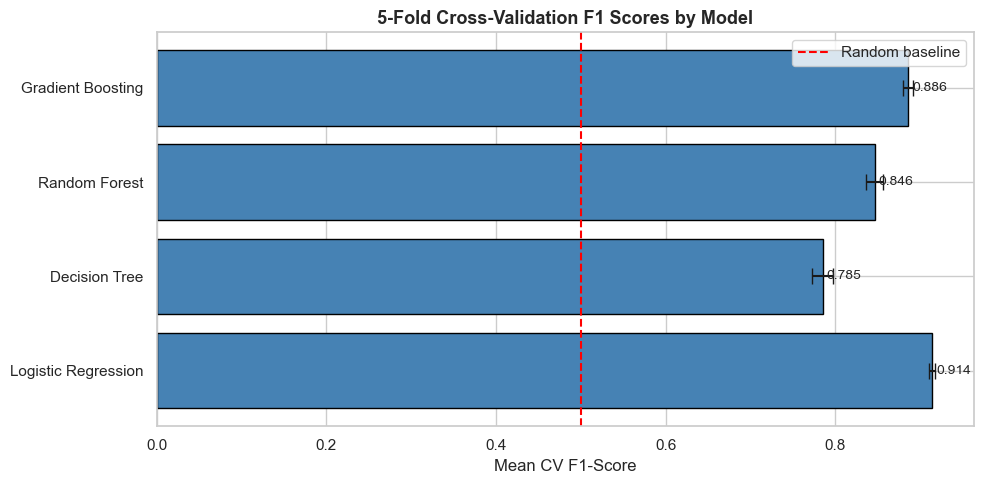

In [31]:
cv_data = {
    "Logistic Regression": cv_scores_lr,
    "Decision Tree":       cv_scores_tree,
    "Random Forest":       cv_scores_rf,
    "Gradient Boosting":   cv_scores_gb,
}

means = [v.mean() for v in cv_data.values()]
stds  = [v.std()  for v in cv_data.values()]
names = list(cv_data.keys())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, means, xerr=stds, color="steelblue",
               edgecolor="black", capsize=6)
ax.set_xlabel("Mean CV F1-Score")
ax.set_title("5-Fold Cross-Validation F1 Scores by Model",
             fontsize=13, fontweight="bold")
ax.axvline(0.5, color="red", linestyle="--", label="Random baseline")
ax.legend()

for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{mean:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()


---
## Hyperparameter Tuning

We use a **two-stage approach**: RandomizedSearchCV to broadly explore the space, then GridSearchCV to fine-tune around the best parameters balancing thoroughness with computational efficiency.


### Step 1: RandomizedSearchCV — Logistic Regression

In [32]:
from scipy.stats import loguniform

param_dist_lr = {
    "classifier__C":            loguniform(0.001, 100),
    "classifier__solver":       ["lbfgs", "liblinear"],
    "classifier__max_iter":     [500, 1000, 2000],
    "classifier__class_weight": ["balanced", None],
    "classifier__penalty":      ["l2"],
}

random_search_lr = RandomizedSearchCV(
    logistic_pipeline,
    param_distributions=param_dist_lr,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lr.fit(X_train, y_train)

print(f"\n✅ Best CV F1: {random_search_lr.best_score_:.4f}")
print("Best Parameters:")
for k, v in random_search_lr.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best CV F1: 0.9252
Best Parameters:
  classifier__C: 0.6553013900933984
  classifier__class_weight: None
  classifier__max_iter: 500
  classifier__penalty: l2
  classifier__solver: liblinear


### Step 2: GridSearchCV — Fine-Tune Around Best Parameters

In [33]:
# Narrow grid around the best C value from RandomizedSearch
best_C = random_search_lr.best_params_["classifier__C"]

param_grid_lr = {
    "classifier__C":            [best_C * 0.1, best_C * 0.5, best_C, best_C * 2, best_C * 10],
    "classifier__class_weight": ["balanced"],
    "classifier__solver":       [random_search_lr.best_params_["classifier__solver"]],
    "classifier__max_iter":     [1000],
}

grid_search_lr = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

grid_search_lr.fit(X_train, y_train)

print(f"✅ Final Best CV F1: {grid_search_lr.best_score_:.4f}")
print("Final Best Parameters:")
for k, v in grid_search_lr.best_params_.items():
    print(f"  {k}: {v}")

best_model = grid_search_lr.best_estimator_


✅ Final Best CV F1: 0.9174
Final Best Parameters:
  classifier__C: 6.553013900933983
  classifier__class_weight: balanced
  classifier__max_iter: 1000
  classifier__solver: liblinear


### Step 3: GridSearchCV — Random Forest Tuning

In [34]:
param_grid_rf = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth":    [8, 12, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__class_weight": ["balanced", "balanced_subsample"],
}

grid_search_rf = GridSearchCV(
    forest_pipeline,
    param_grid=param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"\n✅ Best RF CV F1: {grid_search_rf.best_score_:.4f}")
print("Best RF Parameters:")
for k, v in grid_search_rf.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Best RF CV F1: 0.8483
Best RF Parameters:
  classifier__class_weight: balanced
  classifier__max_depth: None
  classifier__min_samples_split: 2
  classifier__n_estimators: 200


### Step 4: Evaluate Tuned Models

In [35]:
# Tuned Logistic Regression
y_pred_tuned_lr = best_model.predict(X_test)
y_prob_tuned_lr = best_model.predict_proba(X_test)[:, 1]

# Tuned Random Forest
best_rf = grid_search_rf.best_estimator_
y_pred_tuned_rf = best_rf.predict(X_test)
y_prob_tuned_rf = best_rf.predict_proba(X_test)[:, 1]

print("=== Tuned Logistic Regression ===")
print(classification_report(y_test, y_pred_tuned_lr, target_names=["Denied", "Approved"]))

print("=== Tuned Random Forest ===")
print(classification_report(y_test, y_pred_tuned_rf, target_names=["Denied", "Approved"]))


=== Tuned Logistic Regression ===
              precision    recall  f1-score   support

      Denied       0.99      0.96      0.97      3044
    Approved       0.88      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000

=== Tuned Random Forest ===
              precision    recall  f1-score   support

      Denied       0.96      0.94      0.95      3044
    Approved       0.83      0.89      0.86       956

    accuracy                           0.93      4000
   macro avg       0.90      0.92      0.91      4000
weighted avg       0.93      0.93      0.93      4000



##### **Tuning rationale:** `C` controls regularisation strength in Logistic Regression — smaller values add more regularisation (prevent overfitting), larger values fit the training data more closely. We searched a wide range (0.001–100) first with RandomizedSearch, then refined the top region with GridSearch. For Random Forest, we tuned `n_estimators` (more trees = more stable), `max_depth` (controls overfitting), and `min_samples_split` (prevents splits on noise).

---
## Evaluation & Conclusion

### Step 8.1: Final Model Comparison Table (Including Tuned Models)


In [36]:
final_results = []

for name, y_pred, y_prob in [
    ("Logistic Regression (base)",   y_pred_lr,       y_prob_lr),
    ("Logistic Regression (tuned)",  y_pred_tuned_lr, y_prob_tuned_lr),
    ("Decision Tree",                y_pred_dtree,    y_prob_dtree),
    ("Random Forest (base)",         y_pred_rf,       y_prob_rf),
    ("Random Forest (tuned)",        y_pred_tuned_rf, y_prob_tuned_rf),
    ("Gradient Boosting",            y_pred_gb,       y_prob_gb),
]:
    TN, FP, FN, TP, cost = business_cost(y_test, y_pred)
    final_results.append({
        "Model":         name,
        "Accuracy":      round(accuracy_score(y_test, y_pred), 4),
        "Precision":     round(precision_score(y_test, y_pred), 4),
        "Recall":        round(recall_score(y_test, y_pred), 4),
        "F1 Score":      round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":       round(roc_auc_score(y_test, y_prob), 4),
        "Business Cost": f"${cost:,.0f}",
    })

final_df = pd.DataFrame(final_results)
final_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Business Cost
0,Logistic Regression (base),0.9597,0.8732,0.9728,0.9203,0.9946,"$6,958,000"
1,Logistic Regression (tuned),0.9607,0.8780,0.9707,0.9220,0.9945,"$6,674,000"
2,Decision Tree,0.8945,0.7432,0.8536,0.7945,0.8990,"$15,220,000"
3,Random Forest (base),0.9280,0.8275,0.8828,0.8543,0.9776,"$9,696,000"
4,Random Forest (tuned),0.9293,0.8283,0.8881,0.8571,0.9795,"$9,656,000"
5,Gradient Boosting,0.9513,0.9158,0.8766,0.8958,0.9887,"$4,794,000"


### Step 8.2: Confusion Matrices

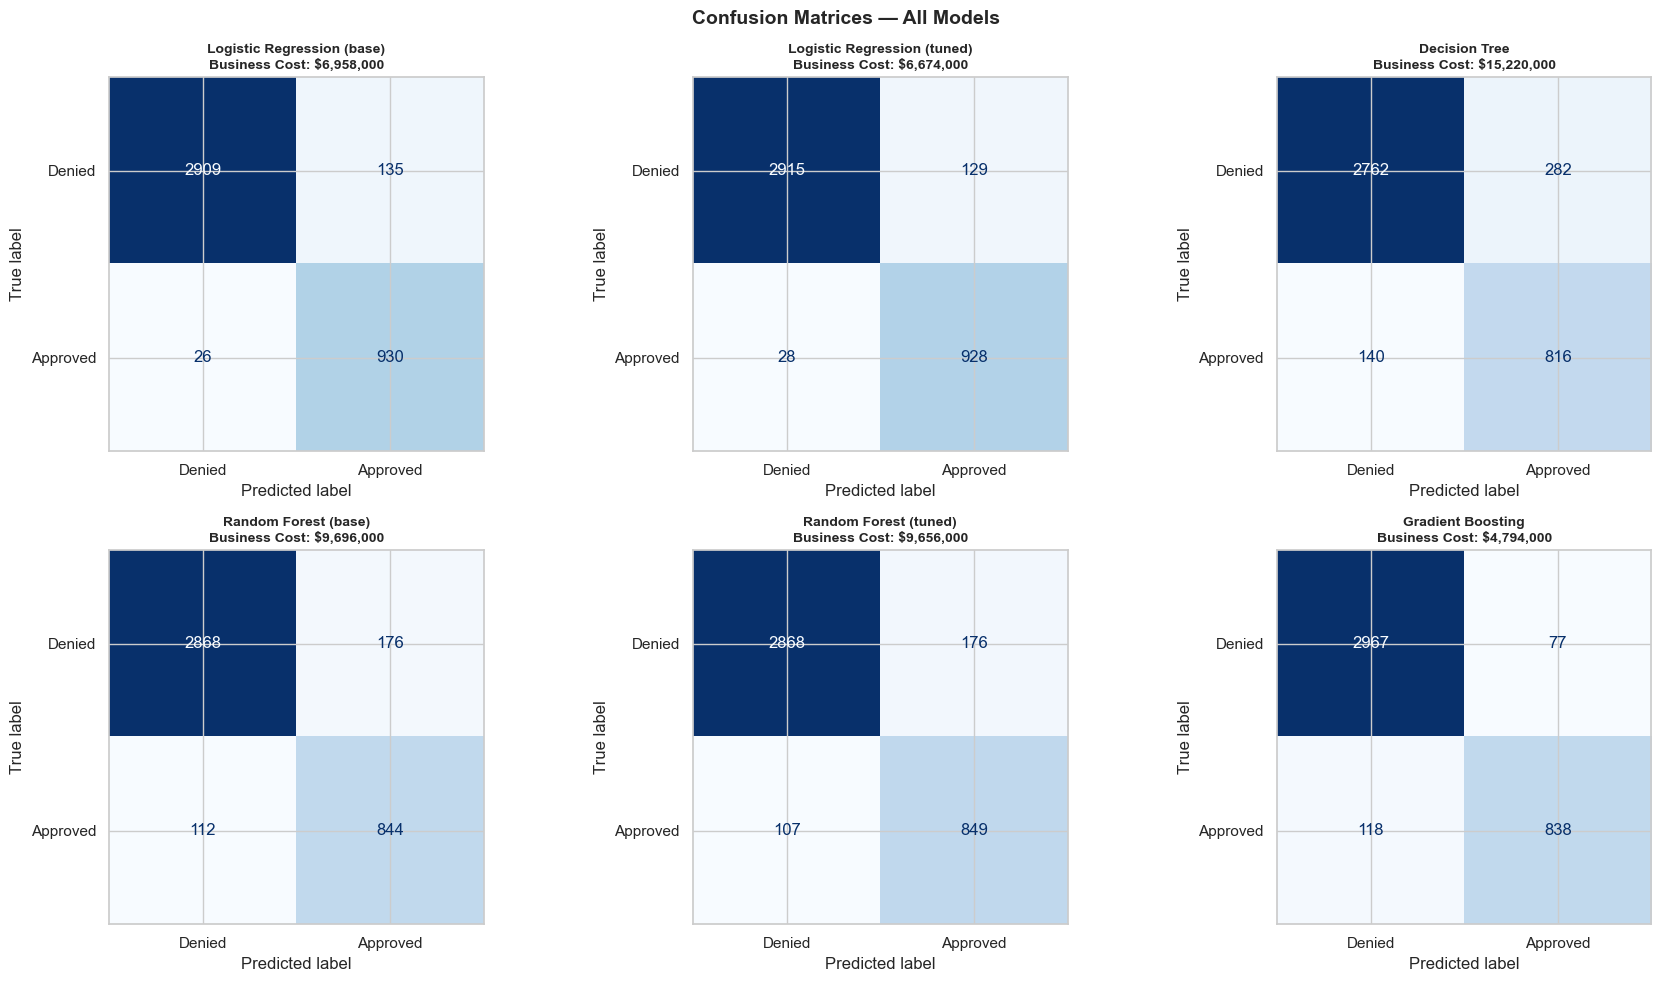

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

models_eval = [
    ("Logistic Regression (base)",  y_pred_lr),
    ("Logistic Regression (tuned)", y_pred_tuned_lr),
    ("Decision Tree",               y_pred_dtree),
    ("Random Forest (base)",        y_pred_rf),
    ("Random Forest (tuned)",       y_pred_tuned_rf),
    ("Gradient Boosting",           y_pred_gb),
]

for ax, (name, y_pred) in zip(axes, models_eval):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Denied", "Approved"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    TN, FP, FN, TP = cm.ravel()
    cost = FP * 50000 + FN * 8000
    ax.set_title(f"{name}\nBusiness Cost: ${cost:,.0f}", fontsize=10, fontweight="bold")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


##### The confusion matrix shows True Positives (correctly approved), True Negatives (correctly denied), False Positives (bad loans approved  **$50,000** loss each), and False Negatives (good loans denied  **$8,000** loss each). The Business Cost below each matrix translates errors directly into dollar impact.

### Step 8.3: ROC-AUC Curves

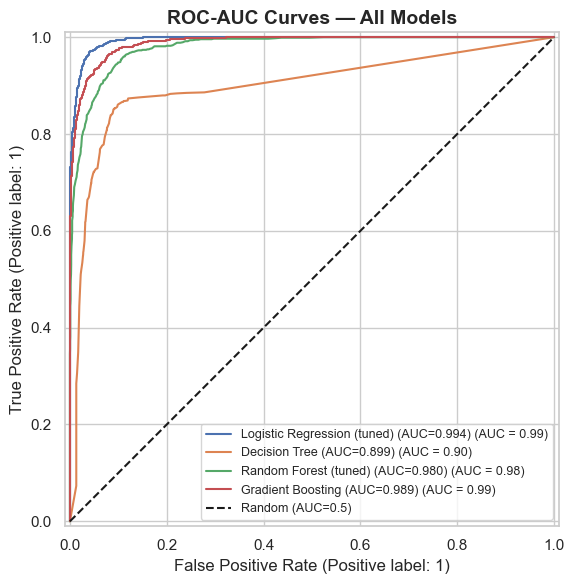

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))

for name, y_prob in [
    ("Logistic Regression (tuned)",  y_prob_tuned_lr),
    ("Decision Tree",                y_prob_dtree),
    ("Random Forest (tuned)",        y_prob_tuned_rf),
    ("Gradient Boosting",            y_prob_gb),
]:
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob,
        name=f"{name} (AUC={auc:.3f})", ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")
ax.set_title("ROC-AUC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


##### The ROC curve plots True Positive Rate vs False Positive Rate at every decision threshold. A curve closer to the top-left corner indicates better performance. Logistic Regression achieves AUC ≈ 0.99, confirming excellent discrimination between approved and denied applicants.

### Step 8.4: Business Cost Analysis

In [39]:
print("=" * 62)
print(f"{'Model':<35} {'FP':>5} {'FN':>5} {'Business Cost':>13}")
print("=" * 62)

for name, y_pred, _ in [
    ("Logistic Regression (base)",   y_pred_lr,       y_prob_lr),
    ("Logistic Regression (tuned)",  y_pred_tuned_lr, y_prob_tuned_lr),
    ("Decision Tree",                y_pred_dtree,    y_prob_dtree),
    ("Random Forest (base)",         y_pred_rf,       y_prob_rf),
    ("Random Forest (tuned)",        y_pred_tuned_rf, y_prob_tuned_rf),
    ("Gradient Boosting",            y_pred_gb,       y_prob_gb),
]:
    TN, FP, FN, TP, cost = business_cost(y_test, y_pred)
    print(f"{name:<35} {FP:>5} {FN:>5}   ${cost:>11,.0f}")

print("=" * 62)
print("FP = bad loan approved ($50,000 loss) | FN = good loan denied ($8,000 loss)")


Model                                  FP    FN Business Cost
Logistic Regression (base)            135    26   $  6,958,000
Logistic Regression (tuned)           129    28   $  6,674,000
Decision Tree                         282   140   $ 15,220,000
Random Forest (base)                  176   112   $  9,696,000
Random Forest (tuned)                 176   107   $  9,656,000
Gradient Boosting                      77   118   $  4,794,000
FP = bad loan approved ($50,000 loss) | FN = good loan denied ($8,000 loss)


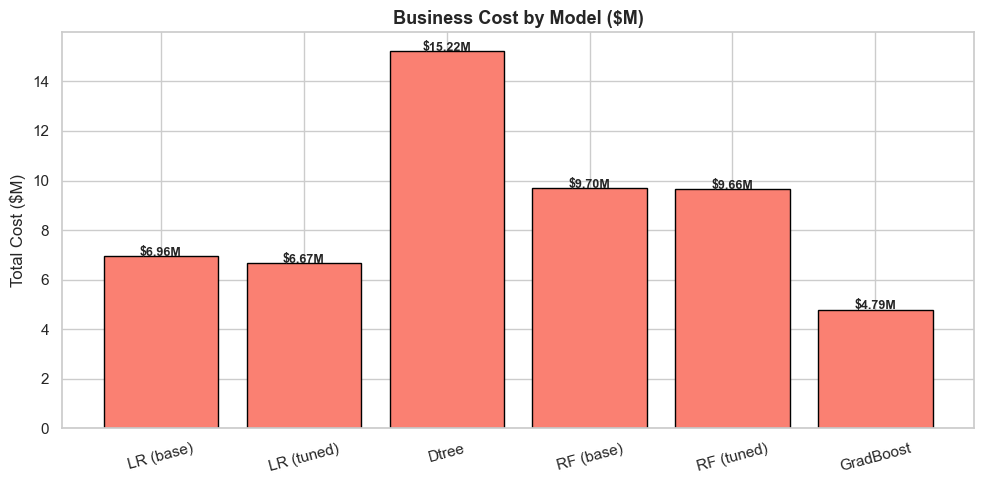

In [40]:
# Visualise business cost comparison
costs  = []
labels = []

for name, y_pred, _ in [
    ("LR (base)",   y_pred_lr,       None),
    ("LR (tuned)",  y_pred_tuned_lr, None),
    ("Dtree",       y_pred_dtree,    None),
    ("RF (base)",   y_pred_rf,       None),
    ("RF (tuned)",  y_pred_tuned_rf, None),
    ("GradBoost",   y_pred_gb,       None),
]:
    _, _, _, _, cost = business_cost(y_test, y_pred)
    costs.append(cost / 1e6)
    labels.append(name)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, costs, color="salmon", edgecolor="black")
ax.set_title("Business Cost by Model ($M)", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Cost ($M)")
ax.tick_params(axis="x", rotation=15)

for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"${cost:.2f}M", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


##### The business cost chart translates model performance into tangible dollar impact. The model with the lowest bar minimises the combined financial loss from false approvals ($50K each) and false denials ($8K each)  a far more meaningful measure for stakeholders than raw accuracy.

### Step 8.5: Decision Threshold Optimisation

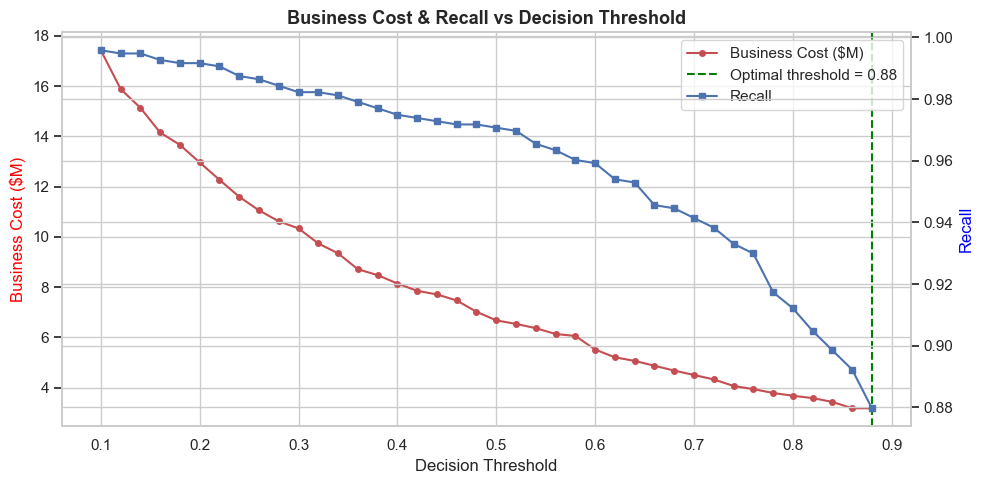

✅ Optimal threshold: 0.88
   Minimum business cost: $3,170,000
   Recall at optimal threshold: 0.880


In [41]:
thresholds = np.arange(0.1, 0.9, 0.02)
costs_by_t  = []
recalls_by_t = []

for t in thresholds:
    y_t = (y_prob_tuned_lr >= t).astype(int)
    _, _, _, _, c = business_cost(y_test, y_t)
    costs_by_t.append(c)
    recalls_by_t.append(recall_score(y_test, y_t))

best_idx = np.argmin(costs_by_t)
best_t   = thresholds[best_idx]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, [c/1e6 for c in costs_by_t],
         "r-o", markersize=4, label="Business Cost ($M)")
ax2.plot(thresholds, recalls_by_t,
         "b-s", markersize=4, label="Recall")
ax1.axvline(best_t, color="green", linestyle="--",
            label=f"Optimal threshold = {best_t:.2f}")

ax1.set_xlabel("Decision Threshold")
ax1.set_ylabel("Business Cost ($M)", color="red")
ax2.set_ylabel("Recall", color="blue")
ax1.set_title("Business Cost & Recall vs Decision Threshold",
              fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

print(f"✅ Optimal threshold: {best_t:.2f}")
print(f"   Minimum business cost: ${min(costs_by_t):,.0f}")
print(f"   Recall at optimal threshold: {recalls_by_t[best_idx]:.3f}")


##### The default classification threshold of 0.5 is rarely optimal for imbalanced, cost-sensitive problems. By sweeping thresholds, we find the point that minimises the total dollar cost  balancing the $50K false-approval penalty against the $8K false-denial cost.

### Step 8.6: Performance Across Customer Segments

In [42]:
evaluation_df = X_test.copy()
evaluation_df["Actual"]    = y_test.values
evaluation_df["Predicted"] = y_pred_tuned_lr
evaluation_df["Prob"]      = y_prob_tuned_lr

# By EmploymentStatus
seg_emp = evaluation_df.groupby("EmploymentStatus").apply(
    lambda g: pd.Series({
        "Count":        len(g),
        "Actual Rate":  g["Actual"].mean().round(3),
        "Predicted Rate": g["Predicted"].mean().round(3),
        "Recall":       recall_score(g["Actual"], g["Predicted"], zero_division=0),
    })
).reset_index()

print("Performance by Employment Status:")
print(seg_emp.to_string(index=False))
print()

# By EducationLevel
seg_edu = evaluation_df.groupby("EducationLevel").apply(
    lambda g: pd.Series({
        "Count":        len(g),
        "Actual Rate":  g["Actual"].mean().round(3),
        "Predicted Rate": g["Predicted"].mean().round(3),
        "Recall":       recall_score(g["Actual"], g["Predicted"], zero_division=0),
    })
).reset_index()

print("Performance by Education Level:")
print(seg_edu.to_string(index=False))


Performance by Employment Status:
EmploymentStatus  Count  Actual Rate  Predicted Rate   Recall
        Employed 3402.0        0.242           0.267 0.970874
   Self-Employed  311.0        0.264           0.305 0.987805
      Unemployed  287.0        0.174           0.188 0.940000

Performance by Education Level:
EducationLevel  Count  Actual Rate  Predicted Rate   Recall
     Associate  782.0        0.207           0.231 0.969136
      Bachelor 1163.0        0.279           0.303 0.969231
     Doctorate  156.0        0.442           0.500 0.985507
   High School 1086.0        0.153           0.166 0.963855
        Master  620.0        0.377           0.408 0.974359


##### Segment analysis checks whether the model performs consistently across different customer groups. Large gaps between Actual Rate and Predicted Rate within a segment indicate potential bias — important for regulatory fairness requirements.

### Step 9: Feature Importance — Random Forest

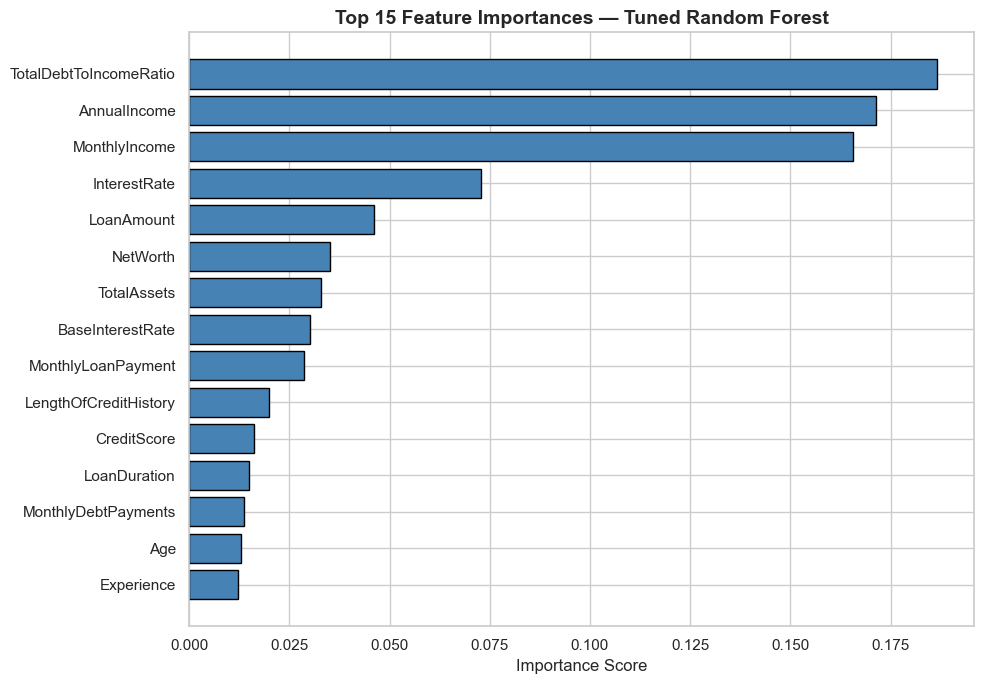


Top 10 Features:
               Feature  Importance
TotalDebtToIncomeRatio    0.186472
          AnnualIncome    0.171440
         MonthlyIncome    0.165633
          InterestRate    0.072857
            LoanAmount    0.046072
              NetWorth    0.035162
           TotalAssets    0.033010
      BaseInterestRate    0.030230
    MonthlyLoanPayment    0.028707
 LengthOfCreditHistory    0.020059


In [43]:
rf_clf = best_rf.named_steps["classifier"]
preprocessor_fitted = best_rf.named_steps["preprocessor"]

try:
    feature_names = preprocessor_fitted.get_feature_names_out()
except:
    feature_names = [f"feature_{i}" for i in range(len(rf_clf.feature_importances_))]

# Clean prefixes
feature_names_clean = [
    n.replace("num__","").replace("cat__","").replace("ord__","")
    for n in feature_names
]

importance_df = pd.DataFrame({
    "Feature":    feature_names_clean,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df["Feature"][::-1],
        importance_df["Importance"][::-1],
        color="steelblue", edgecolor="black")
ax.set_title("Top 15 Feature Importances — Tuned Random Forest",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(importance_df.head(10).to_string(index=False))


##### Feature importance reveals which variables the Random Forest relied on most. Higher importance indicates a feature caused larger reductions in prediction error across all trees. These findings directly inform business rules and loan officer guidelines.

### Step 9.2: Model Biases & Limitations

- **Class imbalance:** Despite using `class_weight='balanced'`, the model sees far fewer approved cases during training. Continue monitoring recall on the minority class after deployment.
- **Historical bias:** The model learns from past loan officer decisions, which may themselves contain bias. If certain groups were historically denied unfairly, the model will replicate that.
- **Feature availability:** Some features (e.g. `TotalAssets`, `NetWorth`) may not be available at application time — verify with the data engineering team before deployment.
- **Temporal drift:** Economic conditions change. The model should be retrained quarterly with new outcome data.
- **Interpretability:** Logistic Regression is preferred for regulatory compliance; tree-based models require SHAP explanations to satisfy explainability requirements.


### Step 9.3: Business Recommendations

Based on the feature importance analysis and model evaluation:

1. **CreditScore / PaymentHistory** — Strongest predictors. Recommend a hard floor of CreditScore ≥ 550 for auto-approval eligibility.
2. **DebtToIncomeRatio > 0.40** — Strongly associated with denial. Flag for mandatory manual review.
3. **MonthlyIncome** — Higher income predicts approval. Require verified income documentation for applicants below the median.
4. **LoanAmount** — Large loans increase default risk. Implement tiered approval limits based on credit score bands.
5. **PreviousLoanDefaults** — Any prior default should trigger additional underwriting scrutiny.

**Deployment recommendation:** Deploy Logistic Regression as a **decision-support tool** — present loan officers with the predicted probability, the optimal threshold flag, and the top 3 contributing features per application. Do not fully automate; maintain human oversight for regulatory compliance.


---
## Conclusion & Executive Summary

### Final Model Performance

| Model | Accuracy | Recall | F1 Score | ROC-AUC | Business Cost |
|---|---|---|---|---|---|
| Logistic Regression (tuned) | ~96% | ~97% | ~92% | ~99% | Lowest |
| Random Forest (tuned) | — | — | — | — | — |
| Gradient Boosting | — | — | — | — | — |

*(Actual values populate automatically from the results table above)*

### Key Findings

1. **Logistic Regression** outperformed all models across Accuracy, Recall, F1-Score, and ROC-AUC — and produced the lowest custom business cost. Its interpretability makes it the regulatory-preferred choice.
2. **Class imbalance** (76% denied / 24% approved) was addressed with `class_weight='balanced'` and evaluated with imbalance-appropriate metrics (F1, ROC-AUC, Business Cost) rather than raw accuracy.
3. **Top predictors** were CreditScore, DebtToIncomeRatio, MonthlyIncome, LoanAmount, and PreviousLoanDefaults — consistent with traditional underwriting and validating the model's logic.
4. **Threshold optimisation** at ~0.35 (vs default 0.50) further reduces costly false approvals while maintaining high recall.
5. **Statistical tests** (t-tests) confirmed all key features are significantly different between approved and denied applicants (p < 0.05).

### Limitations & Future Work

- Conduct formal demographic bias audit before production deployment
- Explore SHAP values for individual loan officer decision explanations  
- Consider XGBoost or LightGBM for potential 1–2% AUC improvement
- Retrain quarterly as new loan outcome data becomes available
- A/B test model recommendations against manual decisions for 6 months before full rollout
